# Backwards tracking

This example demonstrates backward particle tracking in a steady-state flow field, in order to determine the capture zone for a pumping well. The flow system is taken from [Example 1](https://modflow6-examples.readthedocs.io/en/develop/_notebooks/ex-prt-mp7-p01.html) from the MODPATH 7 user guide.

Equivalent MODPATH 7 and MODFLOW 6 PRT simulations are run and their results compared.

First, define units.

In [ ]:
time_unit = "days"
length_unit = "feet"

Sset up a time discretization with a single stress period and time step.

In [ ]:
nstp = 1
perlen = 1000.0
tsmult = 1.0
tdis_pd = [(perlen, nstp, tsmult)]
nper = len(tdis_pd)

Set up a grid discretization: a three-layer model with two relatively permeable layers sandwiching a narrow, relatively impermeable confining bed.

In [ ]:
nlay, nrow, ncol = 3, 21, 20
Lx, Ly = 10000.0, 10500.0
delr, delc = Lx / ncol, Ly / nrow
top = 400.0
bot = [220.0, 200.0, 0.0]

Construct a flow model which will be used by both PRT and MP7.

In [ ]:
from pathlib import Path

example_name = "prt-b"
gwf_name = f"{example_name}-gwf"
base_ws = Path("models") / example_name
gwf_ws = base_ws / "gwf"
gwf_ws.mkdir(exist_ok=True, parents=True)

Construct the GWF simulation.

In [ ]:
import flopy

gwf_sim = flopy.mf6.MFSimulation(
    sim_name=gwf_name,
    exe_name="mf6",
    version="mf6",
    sim_ws=gwf_ws,
)

In [ ]:
tdis = flopy.mf6.ModflowTdis(
    gwf_sim,
    time_units=time_unit,
    nper=nper,
    perioddata=tdis_pd,
)

In [ ]:
gwf = flopy.mf6.ModflowGwf(
    gwf_sim,
    modelname=gwf_name,
    save_flows=True,
)

In [ ]:
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units=length_unit,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=bot,
)

Fully saturated initial conditions. Since the model is steady state it will equilibrate.

In [ ]:
ic = flopy.mf6.ModflowGwfic(gwf, strt=top)

The top layer's cells are convertible. Hydraulic conductivity is greater in the later than the vertical direction.

In [ ]:
kh = [50.0, 0.01, 200.0]
kv = [10.0, 0.01, 20.0]
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=[1, 0, 0],
    k=kh,
    k33=kv,
    save_flows=True,
    save_saturation=True,
    save_specific_discharge=True,
)

Define boundary conditions: a well, a river, and recharge.

In [ ]:
# WEL
wel_q = -150000.0
wel_loc = (2, 10, 9)
wel_pd = [(wel_loc, wel_q)]
wel = flopy.mf6.modflow.mfgwfwel.ModflowGwfwel(
    gwf,
    maxbound=1,
    stress_period_data={0: wel_pd}
)

# RIV
riv_h = 320.0
riv_z = 317.0
riv_c = 1.0e5
riv_iface = 6
riv_iflowface = -1
riv_pd = []
for i in range(nrow):
    riv_pd.append([(0, i, ncol - 1), riv_h, riv_c, riv_z, riv_iface, riv_iflowface])
riv = flopy.mf6.modflow.mfgwfriv.ModflowGwfriv(
    gwf, auxiliary=["iface", "iflowface"], stress_period_data={0: riv_pd}
)

# RCH
rch = 0.005
rch_iface = 6
rch_iflowface = -1
rcha = flopy.mf6.modflow.mfgwfrcha.ModflowGwfrcha(
    gwf,
    recharge=rch,
    auxiliary=["iface", "iflowface"],
    aux=[rch_iface, rch_iflowface],
)

Compute node numbers for the well and river boundary conditions. This will be used for zone assignment, more easily distinguish particle destinations.

In [ ]:
bc_nodes = {}
k, i, j = wel_loc
bc_nodes["well"] = [ncol * (nrow * k + i) + j]
bc_nodes["river"] = []
for rivspec in riv_pd:
    k, i, j = rivspec[0]
    bc_nodes["river"].append(ncol * (nrow * k + i) + j)

Configure output control, enabling comprehensive head and budget reporting.

In [ ]:
headfile_name = f"{gwf_name}.hds"
budgetfile_name = f"{gwf_name}.cbb"

oc = flopy.mf6.modflow.mfgwfoc.ModflowGwfoc(
    gwf,
    pname="oc",
    head_filerecord=[headfile_name],
    budget_filerecord=[budgetfile_name],
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

Create the iterative model solution.

In [ ]:
ims = flopy.mf6.ModflowIms(
    gwf_sim,
    pname="ims",
    complexity="SIMPLE",
    outer_dvclose=1e-6,
    inner_dvclose=1e-6,
    rcloserecord=1e-6,
)

Write and run the flow simulation.

In [100]:
gwf_sim.write_simulation(silent=False)
gwf_sim.run_simulation(silent=False)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model ex1-gwf...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package wel_0...
    writing package riv_0...
INFORMATION: maxbound in ('', 'riv', 'dimensions') changed to 21 based on size of stress_period_data
    writing package oc...
FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mf6
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                          VERSION 6.8.0.dev0+a6a49847
                               ***DEVELOP MODE***

        MODFLOW 6 compiled Jun  1 2026 15:48:17 with GCC version 15.2.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely bes

(True, [])

Load flow results, then plot heads in layer 3.

In [ ]:
hds = gwf.output.head()
head = hds.get_data()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
    ax.set_aspect("equal")
    ax.set_title("Head, layer 3", fontsize=10)
    ax.legend(
        handles=[
            Patch(color="red", label="WEL"),
            Patch(color="blue", label="RIV"),
        ],
    )
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=2)
    mm.plot_grid(alpha=0.25)
    mm.plot_bc("WEL", plotAll=True, color="red")
    mm.plot_bc("RIV", plotAll=True, color="blue")
    pc = mm.plot_array(head, edgecolor="black", alpha=0.25)
    cb = plt.colorbar(pc, shrink=0.25, pad=0.1)
    cb.ax.set_xlabel(r"Head (ft)")
    fig.tight_layout()
    plt.show()

We can now begin setting up the particle tracking models.

Release locations are again defined with flopy's MP7 release-template module, then converted for PRT.  We release particles from the lateral faces of the well cell using MP7 particle input style 2,
subdivision style 1.

In [ ]:
mp7_face_data = flopy.modpath.FaceDataType(
    verticaldivisions1=5,
    verticaldivisions2=5,
    verticaldivisions3=5,
    verticaldivisions4=5,
    horizontaldivisions1=5,
    horizontaldivisions2=5,
    horizontaldivisions3=5,
    horizontaldivisions4=5,
    rowdivisions5=0,
    rowdivisions6=0,
    columndivisions5=0,
    columndivisions6=0,
)
mp7_particle_data = flopy.modpath.LRCParticleData(
    subdivisiondata=[mp7_face_data], lrcregions=[[[*wel_loc, *wel_loc]]]
)
mp7_pg1 = flopy.modpath.ParticleGroupLRCTemplate(
    particlegroupname="PG1",
    particledata=mp7_particle_data,
    filename="pg1.sloc",
)

Define a zone map. Zone 0 is active, zone 1 is the well, zone 2 is the river. Zones are used to identify where particles originate or terminate.

In [ ]:
import numpy as np

izone = np.zeros((nlay, nrow, ncol), dtype=int)
for l, r, c in gwf.modelgrid.get_lrc(bc_nodes["well"]):
    izone[l, r, c] = 1
for l, r, c in gwf.modelgrid.get_lrc(bc_nodes["river"]):
    izone[l, r, c] = 2

In [ ]:
mp7_name = f"{example_name}-mp7"
mp7_ws = base_ws / "mp7"
mp7_ws.mkdir(exist_ok=True, parents=True)

mp7 = flopy.modpath.Modpath7(
    modelname=mp7_name,
    flowmodel=gwf,
    exe_name="mp7",
    model_ws=mp7_ws,
    budgetfilename=budgetfile_name,
    headfilename=headfile_name,
)

porosity = 0.1
mp7_bas = flopy.modpath.Modpath7Bas(
    mp7,
    porosity=porosity,
    defaultiface={"RCH": 6, "EVT": 6}
)

mp7_sim = flopy.modpath.Modpath7Sim(
    mp7,
    simulationtype="combined",
    trackingdirection="backward",
    weaksinkoption="pass_through",
    weaksourceoption="pass_through",
    budgetoutputoption="summary",
    referencetime=[0, 0, 0.0],
    stoptimeoption="extend",
    timepointdata=[500, 1000.0],
    zonedataoption="on",
    zones=izone,
    particlegroups=[mp7_pg1],
)

Write and run the MP7 simulation.

In [111]:
mp7.write_input()
mp7.run_model(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mp7

MODPATH Version 7.2.001   
Program compiled May 26 2026 17:12:29 with GFORTRAN compiler (ver. 12.5.0)      


Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+03  Steady-state flow                                                    

Particle Summary:
         0 particles are pending release.
         0 particles remain active.
       100 particles terminated at boundary faces.
         0 particles terminated at weak sink cells.
         0 particles terminated at weak source cells.
         0 particles terminated at strong source/sink cells.
         0 particles terminated in cells with a specified zone number.
         0 particles were stranded in inactive or dry cells.
         0 particles were unreleased.
         0 particles have an unknown status.
 
Normal termination.                                                        


(True, [])

Load and plot MP7 pathlines.

In [ ]:
import pandas as pd

mp7_pathline_file = flopy.utils.PathlineFile(mp7_ws / f"{mp7_name}.mppth")
mp7_pathlines = pd.concat(
    [pd.DataFrame(pdata) for pdata in mp7_pathline_file.get_alldata()]
)
mp7_pathlines

,particleid,particlegroup,sequencenumber,particleidloc,time,x,y,z,k,node,xloc,yloc,zloc,stressperiod,timestep
0,0,0,0,0,0.000000,4500.000000,5050.000000,20.000000,2,1049,0.000000,0.100000,0.100000,1,1
1,0,0,0,0,0.000000,4500.000000,5050.000000,20.000000,2,1049,0.000000,0.100000,0.100000,1,1
2,0,0,0,0,55.099953,4295.411133,5000.000000,20.183718,2,1048,0.590822,0.000000,0.100919,1,1
3,0,0,0,0,266.722961,4000.000000,4786.688477,20.878109,2,1068,0.000000,0.573377,0.104391,1,1
4,0,0,0,0,672.248657,3500.000000,4600.791992,22.318598,2,1067,0.000000,0.201584,0.111593,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,99,0,99,99,3270.802002,4000.000000,6489.215332,277.520569,0,168,0.000000,0.978431,0.492899,1,1
12,99,0,99,99,3998.984619,3635.062988,6500.000000,309.358093,0,167,0.270126,1.000000,0.762251,1,1
13,99,0,99,99,4000.000000,3634.585449,6500.015137,309.415771,0,147,0.269171,0.000030,0.762647,1,1
14,99,0,99,99,4292.922852,3500.000000,6504.365723,323.101501,0,147,0.000000,0.008732,0.879375,1,1


Plot MP7 pathlines.

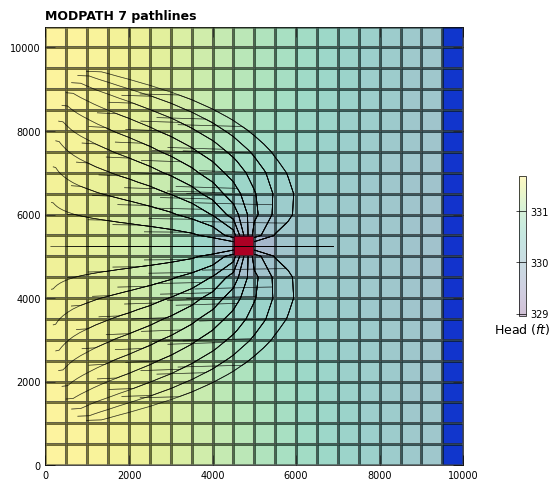

In [113]:
with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
    ax.set_aspect("equal")
    fig.tight_layout()
    flopy.plot.styles.heading(ax, heading="MODPATH 7 pathlines")
    mm = plot_heads(ax, gwf, hds[2, :, :])
    mm.plot_pathline(
        mp7_pathlines, layer="all", colors="black", alpha=0.5, linewidth=0.5
    )

### PRT model

In [114]:
prt_name = f"{example_name}-prt"
prt_ws = base_ws / "prt"
prt_ws.mkdir(exist_ok=True, parents=True)

Create the PRT simulation.

In [115]:
prt_sim = flopy.mf6.MFSimulation(
    sim_name=prt_name, exe_name="mf6", version="mf6", sim_ws=prt_ws
)

Create the temporal discretization.

In [116]:
tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
    prt_sim,
    pname="tdis",
    time_units="DAYS",
    nper=nper,
    perioddata=[(perlen, nstp, tsmult)],
)

Create the PRT model.

In [117]:
prt = flopy.mf6.ModflowPrt(
    prt_sim, modelname=prt_name, model_nam_file=f"{prt_name}.nam"
)

Create the discretization package.

In [ ]:
dis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    prt,
    pname="dis",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    length_units="FEET",
    delr=delr,
    delc=delc,
    top=top,
    botm=bot,
)

Create the model input package.

In [119]:
mip = flopy.mf6.ModflowPrtmip(prt, pname="mip", porosity=porosity, izone=izone)

Create the particle release package. FloPy's `to_prp()` utility converts
the MP7 particle configuration to the format expected by PRT.

In [120]:
release_pts = list(mp7_particle_data.to_prp(gwf.modelgrid))
prp = flopy.mf6.ModflowPrtprp(
    prt,
    nreleasepts=len(release_pts),
    packagedata=release_pts,
    perioddata={0: ["FIRST"]},
    exit_solve_tolerance=1e-5,
    extend_tracking=True,
)

Create the output control package.

PRT can write pathline output to binary or CSV files. Below we enable
both, but will only read the CSV output file.

PRT tracking events (all enabled by default):

- release: record at particle release
- cell exit: record when a particle exits a cell
- timestep end: record at end of each time step
- termination: record when a particle terminates
- weak sink: record when a particle exits a weak sink cell
- user time: record at user-specified times

Some exercises:

Q: How to configure a PRT model like an MP7 endpoint simulation?
A: Select release and termination events only.

Q: How to configure a model like an MP7 timeseries simulation?
A: Select time reporting and provide tracking times.

In [121]:
budgetfile_prt = f"{prt_name}.cbb"
trackfile_prt = f"{prt_name}.trk"
trackcsvfile_prt = f"{prt_name}.trk.csv"
tracktimes = list(range(0, 72000, 1000))

oc = flopy.mf6.ModflowPrtoc(
    prt,
    pname="oc",
    budget_filerecord=[budgetfile_prt],
    track_filerecord=[trackfile_prt],
    trackcsv_filerecord=[trackcsvfile_prt],
    ntracktimes=len(tracktimes),
    tracktimes=[(t,) for t in tracktimes],
    saverecord=[("BUDGET", "ALL")],
)

Create the flow model interface. PRT does not natively support backward
tracking, so we reverse the GWF head and budget files with FloPy first.

In [122]:
head_file = flopy.utils.HeadFile(gwf_ws / headfile_name, tdis=gwf_sim.tdis)
budget_file = flopy.utils.CellBudgetFile(
    gwf_ws / budgetfile_name, precision="double", tdis=gwf_sim.tdis
)

headfile_bkwd_name = f"{headfile_name}_bkwd"
budgetfile_bkwd_name = f"{budgetfile_name}_bkwd"

head_file.reverse(prt_ws / headfile_bkwd_name)
budget_file.reverse(prt_ws / budgetfile_bkwd_name)

fmi = flopy.mf6.ModflowPrtfmi(
    prt,
    packagedata=[
        ("GWFHEAD", headfile_bkwd_name),
        ("GWFBUDGET", budgetfile_bkwd_name),
    ],
)

Create an explicit model solution. PRT uses its own solution procedure,
not the iterative matrix solvers used by GWF and GWT.

In [123]:
ems = flopy.mf6.ModflowEms(
    prt_sim,
    pname="ems",
    filename=f"{prt_name}.ems",
)
prt_sim.register_solution_package(ems, [prt.name])

Write and run the PRT simulation.

In [124]:
prt_sim.write_simulation()
prt_sim.run_simulation(silent=False)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ems...
  writing model ex1-prt...
    writing model name file...
    writing package dis...
    writing package mip...
    writing package prp_0...
    writing package oc...
    writing package fmi...
FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mf6
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                          VERSION 6.8.0.dev0+a6a49847
                               ***DEVELOP MODE***

        MODFLOW 6 compiled Jun  1 2026 15:48:17 with GCC version 15.2.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S

(True, [])

Load PRT pathlines.

In [125]:
prt_pathlines = pd.read_csv(prt_ws / trackcsvfile_prt)
prt_pathlines

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,1,1,1,3,1050,1,1,0,0.0,0.000000,4500.000000,5050.000000,20.000000,NaN
1,1,1,1,1,1,3,1050,1,1,5,0.0,0.000000,4500.000000,5050.000000,20.000000,NaN
2,1,1,1,1,1,3,1050,1,1,1,0.0,0.000000,4500.000000,5050.000000,20.000000,NaN
3,1,1,1,1,1,3,1049,0,1,5,0.0,0.000000,4500.000000,5050.000000,20.000000,NaN
4,1,1,1,1,1,3,1049,0,1,1,0.0,55.099953,4295.411156,5000.000000,20.183717,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2706,1,1,1,1,100,1,168,0,1,1,0.0,3998.985014,3635.062904,6500.000000,309.358115,NaN
2707,1,1,1,1,100,1,148,0,1,5,0.0,4000.000000,3634.585616,6500.015070,309.415776,NaN
2708,1,1,1,1,100,1,148,0,1,1,0.0,4292.923527,3500.000000,6504.365948,323.101509,NaN
2709,1,1,1,1,100,1,147,0,1,1,0.0,4582.804939,3373.095032,6507.929298,337.691216,NaN


Compare PRT and MP7 pathlines in 3D with PyVista.

2026-06-02 07:55:33.365 ( 481.586s) [           1C817]vtkOpenGLRenderWindow.c:876   WARN| vtkCocoaRenderWindow (0x33a51d460): Failed to get red color buffer size (1280)
2026-06-02 07:55:33.365 ( 481.586s) [           1C817]vtkOpenGLRenderWindow.c:886   WARN| vtkCocoaRenderWindow (0x33a51d460): Failed to get green color buffer size (1280)
2026-06-02 07:55:33.365 ( 481.586s) [           1C817]vtkOpenGLRenderWindow.c:896   WARN| vtkCocoaRenderWindow (0x33a51d460): Failed to get blue color buffer size (1280)
2026-06-02 07:55:33.365 ( 481.586s) [           1C817]vtkOpenGLRenderWindow.c:906   WARN| vtkCocoaRenderWindow (0x33a51d460): Failed to get alpha color buffer size (1280)


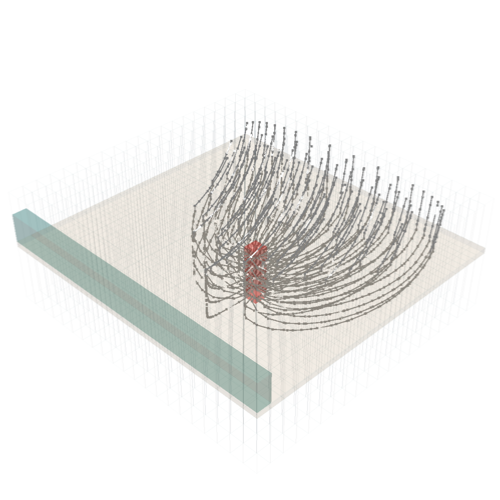

In [ ]:
try:
    import pyvista as pv
    from flopy.export.vtk import Vtk

    vert_exag = 10

    vtk = Vtk(model=gwf, binary=False, vertical_exageration=vert_exag, smooth=False)
    vtk.add_model(gwf)
    vtk.add_pathline_points(mp7_pathlines.to_records(index=False))
    gwf_mesh, mp7_mesh = vtk.to_pyvista()

    # Vtk only supports one pathline set at a time, so rebuild for PRT.
    vtk = Vtk(model=gwf, binary=False, vertical_exageration=vert_exag, smooth=False)
    vtk.add_model(gwf)
    vtk.add_pathline_points(prt_pathlines.to_records(index=False))
    _, prt_mesh = vtk.to_pyvista()

    def get_nn(k, i, j):
        return k * nrow * ncol + i * ncol + j

    riv_mesh = pv.Box(
        bounds=[
            gwf.modelgrid.extent[1] - delc,
            gwf.modelgrid.extent[1],
            gwf.modelgrid.extent[2],
            gwf.modelgrid.extent[3],
            bot[0] * vert_exag,
            hds[(0, 0, ncol - 1)] * vert_exag,
        ]
    )
    well_cellid = get_nn(0, *wel_loc[1:])
    well_points = gwf.modelgrid.verts[gwf.modelgrid.iverts[well_cellid]]
    well_xs, well_ys = list(zip(*well_points))
    wel_mesh = pv.Box(
        bounds=[
            min(well_xs),
            max(well_xs),
            min(well_ys),
            max(well_ys),
            bot[-1] * vert_exag,
            bot[-2] * vert_exag,
        ]
    )
    bed_mesh = pv.Box(
        bounds=[
            gwf.modelgrid.extent[0],
            gwf.modelgrid.extent[1],
            gwf.modelgrid.extent[2],
            gwf.modelgrid.extent[3],
            bot[1] * vert_exag,
            bot[0] * vert_exag,
        ]
    )

    pv.set_jupyter_backend("static")
    p = pv.Plotter(window_size=[500, 500], notebook=True)
    p.enable_anti_aliasing()
    p.add_mesh(gwf_mesh, opacity=0.025, style="wireframe")
    p.add_mesh(mp7_mesh, point_size=5, line_width=2.5, smooth_shading=True, color="white")
    p.add_mesh(prt_mesh, point_size=5, line_width=2.5, smooth_shading=True, color="gray")
    p.add_mesh(riv_mesh, color="teal", opacity=0.2)
    p.add_mesh(wel_mesh, color="red", opacity=0.3)
    p.add_mesh(bed_mesh, color="tan", opacity=0.1)
    p.show()
except ImportError:
    print("PyVista not available.")

## Capture area

Filter pathlines to termination points (ireason == 3) and compute the
convex hull to estimate the well's capture area.

In [127]:
termination_pts = prt_pathlines[prt_pathlines.ireason == 3].set_index("irpt")[
    ["x", "y", "z"]
]
termination_pts

,x,y,z
irpt,,,
1,177.363694,3355.882832,338.959425
2,134.642765,4209.050362,338.948162
3,117.299775,5250.000000,338.943809
4,134.642765,6290.949638,338.948162
5,177.363694,7144.117168,338.959425
...,...,...,...
96,2607.428585,6153.042255,338.053721
97,2743.589741,6406.622504,338.053721
98,2910.816824,6562.599992,338.063757


Build a multi-point geometry and compute the convex hull.

Capture area: 25057419.180 sq feet,     0.899 sq mi


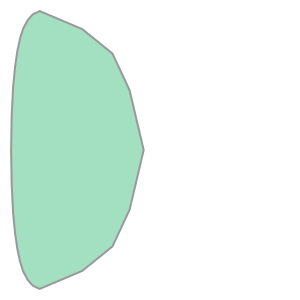

In [128]:
term_pts = MultiPoint(termination_pts.to_numpy())
chull = convex_hull(term_pts)
chull_area_mi = chull.area / (5280 * 5280)
print(f"Capture area: {chull.area:9.3f} sq {length_units}, {chull_area_mi:9.3f} sq mi")
chull

Plot pathlines with the capture area overlaid.

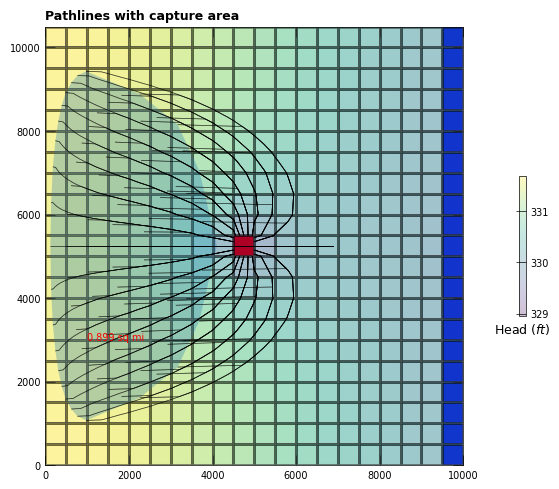

In [129]:
with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
    ax.set_aspect("equal")
    fig.tight_layout()
    flopy.plot.styles.heading(ax, heading="Pathlines with capture area")
    mm = plot_heads(ax, gwf, hds[2, :, :])
    mm.plot_pathline(
        prt_pathlines, layer="all", colors="black", alpha=0.5, linewidth=0.5
    )
    chull_xs, chull_ys, _ = map(list, zip(*list(chull.exterior.coords)))
    ax.fill(chull_xs, chull_ys, alpha=0.3)
    ax.annotate(f"{chull_area_mi:.3f} sq mi", (1000, 3000), color="red")

Now, we can determine a travel time distribution and plot endpoint colors by travel time.

In [130]:
termination_pts = prt_pathlines[prt_pathlines.ireason == 3].set_index("irpt")
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
irpt,,,,,,,,,,,,,,,
1,1,1,1,1,1,281,0,2,3,0.0,16160.109528,177.363694,3355.882832,338.959425,NaN
2,1,1,1,1,1,241,0,2,3,0.0,16082.258255,134.642765,4209.050362,338.948162,NaN
3,1,1,1,1,1,201,0,2,3,0.0,16051.361980,117.299775,5250.000000,338.943809,NaN
4,1,1,1,1,1,161,0,2,3,0.0,16082.258255,134.642765,6290.949638,338.948162,NaN
5,1,1,1,1,1,121,0,2,3,0.0,16160.109528,177.363694,7144.117168,338.959425,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,1,1,1,1,166,0,2,3,0.0,4147.083665,2607.428585,6153.042255,338.053721,NaN
97,1,1,1,1,1,166,0,2,3,0.0,4178.811007,2743.589741,6406.622504,338.053721,NaN
98,1,1,1,1,1,146,0,2,3,0.0,4296.979071,2910.816824,6562.599992,338.063757,NaN


In [131]:
termination_pts.t.describe()

count      100.000000
mean      9784.347007
std       5940.080331
min       4050.335958
25%       5546.056765
50%       7793.218107
75%      11847.683883
max      45040.180878
Name: t, dtype: float64

<Axes: ylabel='Frequency'>

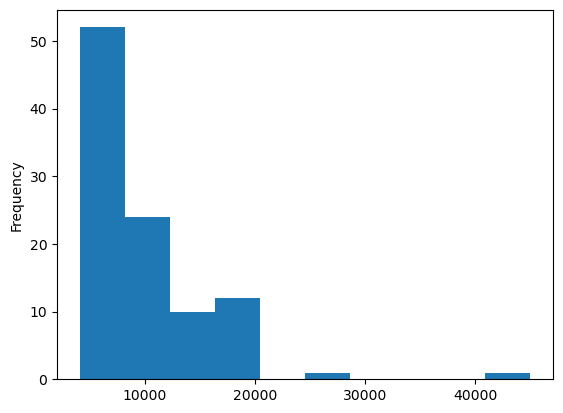

In [132]:
termination_pts.t.plot(kind="hist")

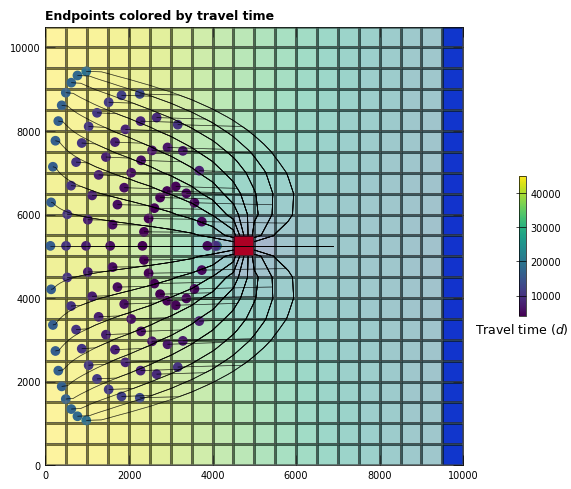

In [133]:
with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
    ax.set_aspect("equal")
    fig.tight_layout()
    flopy.plot.styles.heading(ax, heading="Endpoints colored by travel time")
    mm = plot_heads(ax, gwf, hds[2, :, :], colorbar=False)
    mm.plot_pathline(
        prt_pathlines, layer="all", colors="black", alpha=0.5, linewidth=0.5
    )
    pc = ax.scatter(termination_pts.x, termination_pts.y, c=termination_pts.t)
    cb = plt.colorbar(pc, shrink=0.25, pad=0.1)
    cb.ax.set_xlabel(r"Travel time ($d$)")

Finally, a teaser of a soon-forthcoming [MF6 native backwards tracking capability](https://github.com/MODFLOW-ORG/modflow6/pull/2790)...

In [ ]:
from shutil import which
from flopy.utils.get_modflow import run_main as get_modflow

get_modflow(
    Path(which("mf6")).parent,
    owner="wpbonelli",
    repo="modflow6",
    release_id="6.8.0.dev0+prtbwd",
    force=True,
)

In [ ]:
from flopy.mf6.utils.generate_classes import generate_classes

generate_classes(
    owner="wpbonelli",
    repo="modflow6",
    ref="backward-tracking",
    developmode=True,
)

In [ ]:
fmi = flopy.mf6.ModflowPrtfmi(
    prt,
    backward=True,
    packagedata=[
        ("GWFHEAD", headfile_name),
        ("GWFBUDGET", budgetfile_name),
    ],
)

In [ ]:
prt_sim.write_simulation()
prt_sim.run_simulation()